In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_poisson_deviance
from preprocessing.preprocessing_utils import preprocess_for_tree

In [7]:
# EVALUATION METRICS

def d_squared_poisson(y_true, y_pred, w):
    """Calculates D^2. Print Model Deviance, Null Deviance, D^2"""
    
    # Devinace of model
    dev_model = mean_poisson_deviance(y_true, y_pred, sample_weight=w)
    
    # Intercept only
    mu = np.average(y_true, weights=w)
    y_null = np.full_like(y_true, mu)
    dev_null = mean_poisson_deviance(y_true, y_null, sample_weight=w)
    
    # D^2
    d2 = 1 - (dev_model / dev_null)
    
    
    print("D² calculation")
    print(f"Null deviance (Baseline): {dev_null:.5f}")
    print(f"Model deviance:           {dev_model:.5f}")
    print(f"D^2 Score:                {d2:.2%}")
    print(f"----------")
    
    return d2

def plot_lorenz_curve(y_true, y_pred, w, title="Lorenz Curve"):
    
    """Gini coefficient visualization. Prints AUC and Gini values."""
    
    # Sort by predicted risk
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    data = data.sort_values('Pred')
    
     # Cumulative distributions
    data['CumExposure'] = data['Weight'].cumsum() / data['Weight'].sum()
    data['CumClaims'] = (data['True'] * data['Weight']).cumsum() / (data['True'] * data['Weight']).sum()
    
     # Gini Calculation
    auc = np.trapz(data['CumClaims'], data['CumExposure'])
    gini = 1 - 2 * auc 
    
    
    print(f"Gini Calculation")
    print(f"AUC: {auc:.5f}")
    print(f"Gini :{gini:.5f}")
    print(f"---------------")

    
    plt.figure(figsize=(6, 6))
    plt.plot(data['CumExposure'], data['CumClaims'], label=f'Model (Gini: {gini:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random (Gini: 0.0)')
    plt.xlabel('Cumulative Exposure (sorted by Pred Risk)')
    plt.ylabel('Cumulative Actual Claims')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return gini

def plot_calibration(y_true, y_pred, w, n_bins=10, title="Calibration Plot"):
    """ Splits the data into risk bins, compares Average Predicted Risk vs Average Actual Risk.Prints values"""
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    
    #Binning, handles cases with many identical predictions
    try:
        data['Bin'] = pd.qcut(data['Pred'], n_bins, duplicates='drop')
    except:
        data['Bin'] = pd.cut(data['Pred'], n_bins)
        
    # Calculate Weighted Averages for each bin
    grouped = data.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'AvgPred': np.average(x['Pred'], weights=x['Weight']),
            'AvgTrue': np.average(x['True'], weights=x['Weight']),
            'Exposure': x['Weight'].sum(),
            'Count': len(x)
        })
    )
    
   
    print(f"\n---{title} Data ---")
    
    print_df = grouped.copy()
    print_df['Diff'] = print_df['AvgPred'] - print_df['AvgTrue']
    print_df['Error %'] = (print_df['Diff'] / print_df['AvgTrue']) * 100
    
    
    print(print_df[['AvgPred', 'AvgTrue', 'Diff', 'Exposure']].to_string(float_format="%.4f"))
    print("------------------------------------------------\n")
    
    
   
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(grouped))
    width = 0.35
    
    ax1.bar(x - width/2, grouped['AvgPred'], width, label='Predicted Rate', alpha=0.8, color='teal')
    ax1.bar(x + width/2, grouped['AvgTrue'], width, label='Actual Rate', alpha=0.7, color='slategrey')
    
    ax1.set_xlabel('Risk Groups (Low -> High)')
    ax1.set_ylabel('Claim Rate')
    ax1.set_title(title)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i+1}" for i in x])
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(x, grouped['Exposure'], color='red', linestyle='--', marker='o', label='Exposure Vol', alpha=0.3)
    ax2.set_ylabel('Total Exposure (Years)')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title="Feature Importance"):
    """ Visualizes and prints which features are most impotant for DT ."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
 
    print(f"\n--- {title} Scores ---")
    print(f"{'Rank':<5} {'Feature':<20} {'Importance':<10}")
    print("-" * 40)
    
    # Print top 15 features or all if fewer
    top_n = min(15, len(feature_names))
    for i in range(top_n):
        idx = indices[i]
        print(f"{i+1:<5} {feature_names[idx]:<20} {importances[idx]:.5f}")
    print("--------------------------------\n")
    
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.xlabel("Feature")
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.show()
    


    

In [3]:

# DATA LOADING AND PREPROCESSING
 
train = pd.read_csv("../data/claims_train.csv")
test  = pd.read_csv("../data/claims_test.csv")
 
X_tr, y_tr_rate, w_tr = preprocess_for_tree(train)
X_te, y_te_rate, w_te = preprocess_for_tree(test)
feature_names = list(X_tr.columns) 
print(f"Feature names extracted: {feature_names}")

# Convert to numpy for sklearn, efficiency
X_train = X_tr.values.astype(np.float32)
y_train = y_tr_rate.values.astype(np.float32)
w_train = w_tr.values.astype(np.float32)

X_test = X_te.values.astype(np.float32)
y_test = y_te_rate.values.astype(np.float32)
w_test = w_te.values.astype(np.float32)

Feature names extracted: ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area_Int', 'VehBrand_B10', 'VehBrand_B11', 'VehBrand_B12', 'VehBrand_B13', 'VehBrand_B14', 'VehBrand_B2', 'VehBrand_B3', 'VehBrand_B4', 'VehBrand_B5', 'VehBrand_B6', 'VehGas_Regular', 'Region_R21', 'Region_R22', 'Region_R23', 'Region_R24', 'Region_R25', 'Region_R26', 'Region_R31', 'Region_R41', 'Region_R42', 'Region_R43', 'Region_R52', 'Region_R53', 'Region_R54', 'Region_R72', 'Region_R73', 'Region_R74', 'Region_R82', 'Region_R83', 'Region_R91', 'Region_R93', 'Region_R94']


In [4]:

# M1: DECISION TREE 
# Hyperparameter Tuning, Depth and  Min Leaf

kf = KFold(n_splits=5, shuffle=True, random_state=7)

depth_grid = [6, 7, 8, 9, 10]
# Minimum exposure per leaf (in policy years)
leaf_weight_grid = [10, 20, 30, 50, 100, 250] 

best_params = {"depth": None, "leaf_w": None, "score": np.inf}

print("Starting Grid Search for Depth and Leaf Weight")

for d in depth_grid:
    for lw in leaf_weight_grid:
        fold_deviances = []
        
        for train_idx, val_idx in kf.split(X_train):
            X_f, y_f, w_f = X_train[train_idx], y_train[train_idx], w_train[train_idx]
            X_v, y_v, w_v = X_train[val_idx], y_train[val_idx], w_train[val_idx]
            
            # Convert leaf exposure to sklearn fraction
            total_w = w_f.sum()
            frac = float(lw / total_w)
            frac = min(frac, 0.5) # Safety cap
            
            # Fit Model
            dt = DecisionTreeRegressor(
                criterion="poisson", 
                max_depth=d,
                min_weight_fraction_leaf=frac,
                random_state=7
            )
            dt.fit(X_f, y_f, sample_weight=w_f)
            
            # Predict and evaluate
            preds = dt.predict(X_v)
            dev = mean_poisson_deviance(y_v, preds, sample_weight=w_v)
            fold_deviances.append(dev)
            
        avg_dev = np.mean(fold_deviances)
        print(f"Depth: {d}, Leaf Exp: {lw} -> Deviance: {avg_dev:.5f}")
        
        if avg_dev < best_params["score"]:
            best_params = {"depth": d, "leaf_w": lw, "score": avg_dev}

print(f"\nBest Parameters Found: {best_params}")

Starting Grid Search for Depth and Leaf Weight
Depth: 6, Leaf Exp: 10 -> Deviance: 0.58112
Depth: 6, Leaf Exp: 20 -> Deviance: 0.58105
Depth: 6, Leaf Exp: 30 -> Deviance: 0.58098
Depth: 6, Leaf Exp: 50 -> Deviance: 0.58094
Depth: 6, Leaf Exp: 100 -> Deviance: 0.58096
Depth: 6, Leaf Exp: 250 -> Deviance: 0.58091
Depth: 7, Leaf Exp: 10 -> Deviance: 0.57953
Depth: 7, Leaf Exp: 20 -> Deviance: 0.57934
Depth: 7, Leaf Exp: 30 -> Deviance: 0.57925
Depth: 7, Leaf Exp: 50 -> Deviance: 0.57927
Depth: 7, Leaf Exp: 100 -> Deviance: 0.57955
Depth: 7, Leaf Exp: 250 -> Deviance: 0.58026
Depth: 8, Leaf Exp: 10 -> Deviance: 0.58049
Depth: 8, Leaf Exp: 20 -> Deviance: 0.58028
Depth: 8, Leaf Exp: 30 -> Deviance: 0.57988
Depth: 8, Leaf Exp: 50 -> Deviance: 0.57974
Depth: 8, Leaf Exp: 100 -> Deviance: 0.57990
Depth: 8, Leaf Exp: 250 -> Deviance: 0.58039
Depth: 9, Leaf Exp: 10 -> Deviance: 0.58269
Depth: 9, Leaf Exp: 20 -> Deviance: 0.58220
Depth: 9, Leaf Exp: 30 -> Deviance: 0.58187
Depth: 9, Leaf Exp: 50 

In [5]:

# Cost Complexity Pruning 

total_w_train = w_train.sum()
best_frac = float(best_params["leaf_w"] / total_w_train)

clf_large = DecisionTreeRegressor(
    criterion="poisson",
    max_depth=best_params["depth"],
    min_weight_fraction_leaf=best_frac,
    random_state=7
)
path = clf_large.cost_complexity_pruning_path(X_train, y_train, sample_weight=w_train)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[ccp_alphas >= 0] 

# Limit alphas, reasonable number for speed
if len(ccp_alphas) > 20:
    indices = np.linspace(0, len(ccp_alphas)-1, 20, dtype=int)
    ccp_alphas = ccp_alphas[indices]

print(f"\nScanning {len(ccp_alphas)} pruning candidates (alpha)...")

# CV, find optimal Alpha
alpha_scores = []
for alpha in ccp_alphas:
    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_f, y_f, w_f = X_train[train_idx], y_train[train_idx], w_train[train_idx]
        X_v, y_v, w_v = X_train[val_idx], y_train[val_idx], w_train[val_idx]
        
        frac_fold = float(best_params["leaf_w"] / w_f.sum())
        
        dt_pruned = DecisionTreeRegressor(
            criterion="poisson",
            max_depth=best_params["depth"],
            min_weight_fraction_leaf=frac_fold,
            ccp_alpha=alpha,
            random_state=7
        )
        dt_pruned.fit(X_f, y_f, sample_weight=w_f)
        preds = dt_pruned.predict(X_v)
        fold_scores.append(mean_poisson_deviance(y_v, preds, sample_weight=w_v))
    
    alpha_scores.append(np.mean(fold_scores))
    print(f"Alpha: {alpha:.8f} -> CV Deviance: {alpha_scores[-1]:.5f}")

best_alpha_idx = np.argmin(alpha_scores)
best_alpha = ccp_alphas[best_alpha_idx]
print(f"Best Alpha: {best_alpha:.6f} with CV Deviance: {min(alpha_scores):.5f}")


Scanning 25 pruning candidates (alpha)...
Alpha: 0.00000000 -> CV Deviance: 0.57925
Alpha: 0.00000279 -> CV Deviance: 0.57925
Alpha: 0.00000588 -> CV Deviance: 0.57923
Alpha: 0.00000776 -> CV Deviance: 0.57920
Alpha: 0.00001034 -> CV Deviance: 0.57919
Alpha: 0.00001111 -> CV Deviance: 0.57919
Alpha: 0.00001307 -> CV Deviance: 0.57904
Alpha: 0.00001364 -> CV Deviance: 0.57900
Alpha: 0.00001599 -> CV Deviance: 0.57902
Alpha: 0.00001716 -> CV Deviance: 0.57898
Alpha: 0.00001873 -> CV Deviance: 0.57896
Alpha: 0.00002146 -> CV Deviance: 0.57889
Alpha: 0.00002569 -> CV Deviance: 0.57880
Alpha: 0.00002977 -> CV Deviance: 0.57876
Alpha: 0.00003381 -> CV Deviance: 0.57881
Alpha: 0.00003955 -> CV Deviance: 0.57883
Alpha: 0.00004985 -> CV Deviance: 0.57893
Alpha: 0.00006368 -> CV Deviance: 0.57951
Alpha: 0.00006993 -> CV Deviance: 0.57973
Alpha: 0.00008379 -> CV Deviance: 0.57986
Alpha: 0.00014068 -> CV Deviance: 0.58113
Alpha: 0.00020599 -> CV Deviance: 0.58358
Alpha: 0.00026325 -> CV Deviance:

D² calculation
Null deviance (Baseline): 0.63304
Model deviance:           0.58488
D^2 Score:                7.61%
----------

--- Final Test Set Performance (Reference M1) ---
Mean Poisson Deviance: 0.58488
D^2 (Deviance Explained): 7.61%

Plotting Gini...
Gini Calculation
AUC: 0.34331
Gini :0.31338
---------------


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28296\1769709767.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(data['CumClaims'], data['CumExposure'])


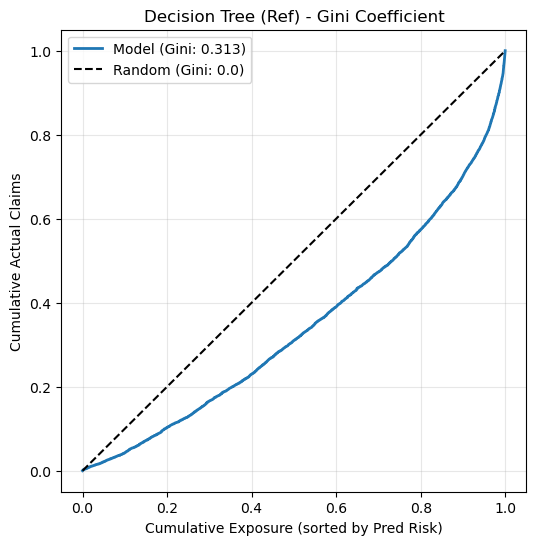


---Calibration Plot Data ---
                               AvgPred  AvgTrue    Diff   Exposure
Bin                                                               
(0.024999999999999998, 0.047]   0.0420   0.0462 -0.0042  8782.1738
(0.047, 0.0626]                 0.0602   0.0583  0.0019  9114.1426
(0.0626, 0.0694]                0.0694   0.0718 -0.0024  5963.2715
(0.0694, 0.0819]                0.0815   0.0789  0.0026 25132.2246
(0.0819, 0.11]                  0.0947   0.1006 -0.0059  7813.3862
(0.11, 0.121]                   0.1169   0.1193 -0.0023  6077.7783
(0.121, 0.164]                  0.1553   0.1652 -0.0098  4437.4590
(0.164, 1.429]                  0.3899   0.3938 -0.0039  4306.4272
------------------------------------------------



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28296\1769709767.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = data.groupby('Bin', observed=False).apply(


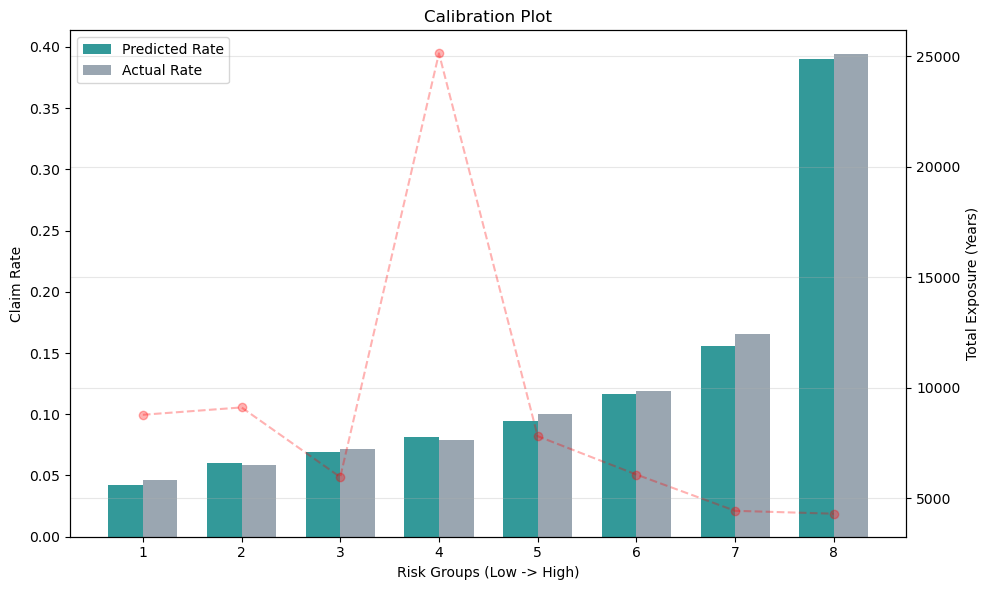


--- Feature Importance Scores ---
Rank  Feature              Importance
----------------------------------------
1     BonusMalus           0.34047
2     VehAge               0.32591
3     VehBrand_B12         0.10671
4     VehPower             0.08778
5     VehGas_Regular       0.06283
6     DrivAge              0.05870
7     Density              0.01031
8     Region_R41           0.00339
9     Region_R91           0.00245
10    Region_R83           0.00146
11    VehBrand_B2          0.00000
12    VehBrand_B5          0.00000
13    VehBrand_B4          0.00000
14    VehBrand_B3          0.00000
15    VehBrand_B11         0.00000
--------------------------------



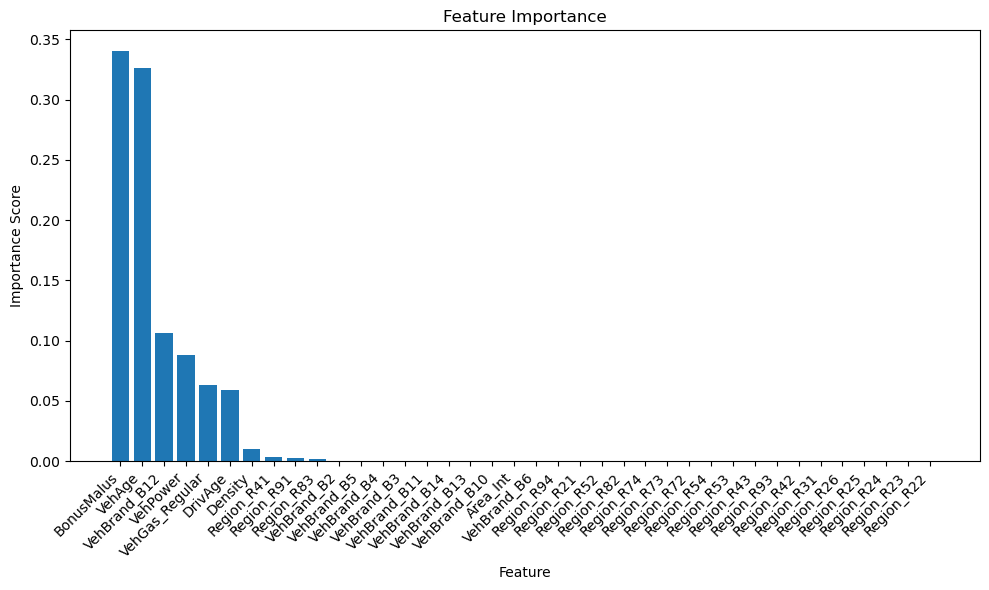

In [8]:

#  FINAL MODEL AND EVALUATION


final_model = DecisionTreeRegressor(
    criterion="poisson",
    max_depth=best_params["depth"],
    min_weight_fraction_leaf=best_frac,
    ccp_alpha=best_alpha,
    random_state=7
)

final_model.fit(X_train, y_train, sample_weight=w_train)
test_preds = final_model.predict(X_test)

# Metrics
test_deviance = mean_poisson_deviance(y_test, test_preds, sample_weight=w_test)
d2 = d_squared_poisson(y_test, test_preds, w_test)

print("\n--- Final Test Set Performance (Reference M1) ---")
print(f"Mean Poisson Deviance: {test_deviance:.5f}")
print(f"D^2 (Deviance Explained): {d2:.2%}")

print("\nPlotting Gini...")
gini_score = plot_lorenz_curve(y_test, test_preds, w_test, title="Decision Tree (Ref) - Gini Coefficient")

#Calibration Plot
plot_calibration(y_test, test_preds, w_test, n_bins=10)

# Feature Importance
feature_names = list(X_tr.columns) 
plot_feature_importance(final_model, feature_names)